In [ ]:
import gdown
import zipfile
import os

# Cсылка на архив
url = "https://drive.google.com/file/d/1D1AwVVol3uPn9nEzxpSst5VBHxseklbn/view?usp=sharing"

# Извлекаем ID файла из ссылки
file_id = url.split('/d/')[1].split('/view')[0]
print(f"ID файла: {file_id}")

# Скачиваем файл
!gdown https://drive.google.com/uc?id={file_id}

# Найдем имя скачанного файла
downloaded_files = [f for f in os.listdir('.') if f.endswith('.zip')]
if downloaded_files:
    archive_name = downloaded_files[0]
    print(f"Скачан архив: {archive_name}")
else:
    print("Файл не скачался или это не zip")

In [ ]:
# Распаковываем архив
if 'archive_name' in locals():
    with zipfile.ZipFile(archive_name, 'r') as zip_ref:
        zip_ref.extractall('./kitti_data')
    print("Архив распакован в папку ./kitti_data")

    # Смотрим, что внутри
    print("\nСодержимое папки kitti_data:")
    !ls -la ./kitti_data

In [ ]:
# Автоматически находим путь к папке oxts/data
import glob

# Ищем все папки oxts/data
oxts_paths = glob.glob('./kitti_data/**/oxts/data', recursive=True)

if oxts_paths:
    oxts_path = oxts_paths[0]
    print(f"Найдена папка с данными: {oxts_path}")

    # Проверяем, есть ли там txt файлы
    txt_files = glob.glob(os.path.join(oxts_path, '*.txt'))
    print(f"Найдено {len(txt_files)} txt-файлов")
    if txt_files:
        print(f"Пример: {os.path.basename(txt_files[0])}")
else:
    print("Папка oxts/data не найдена!")
    print("Вот что есть в распакованном архиве:")
    !find ./kitti_data -type d | head -20

In [ ]:
import numpy as np
import pandas as pd

if oxts_paths:
    oxts_path = oxts_paths[0]

    # Читаем все файлы data
    data_files = sorted([f for f in os.listdir(oxts_path) if f.endswith('.txt')])
    print(f"Загружаем {len(data_files)} файлов...")

    all_data = []
    for f in data_files[:10]:  # Для теста загрузим первые 10
        file_path = os.path.join(oxts_path, f)
        data = np.loadtxt(file_path)
        all_data.append(data)

    df = pd.DataFrame(all_data)
    df.columns = ['lat', 'lon', 'alt', 'roll', 'pitch', 'yaw', 'vn', 've', 'vf', 'vl', 'vu',
                  'ax', 'ay', 'az', 'af', 'al', 'au', 'wx', 'wy', 'wz', 'wf', 'wl', 'wu',
                  'pos_accuracy', 'vel_accuracy', 'navstat', 'numsats', 'posmode', 'velmode', 'orimode']

    print("\nДанные загружены успешно!")
    print(df[['lat', 'lon', 'ax', 'ay', 'az']].head())

Загружаем все данные...
Загружено 108 записей
Общая дистанция по GPS: 107.11 м
Шум измерения GPS: 0.0655 м
Шум акселерометра: 0.1289 м/с²
Запускаем фильтр Калмана...


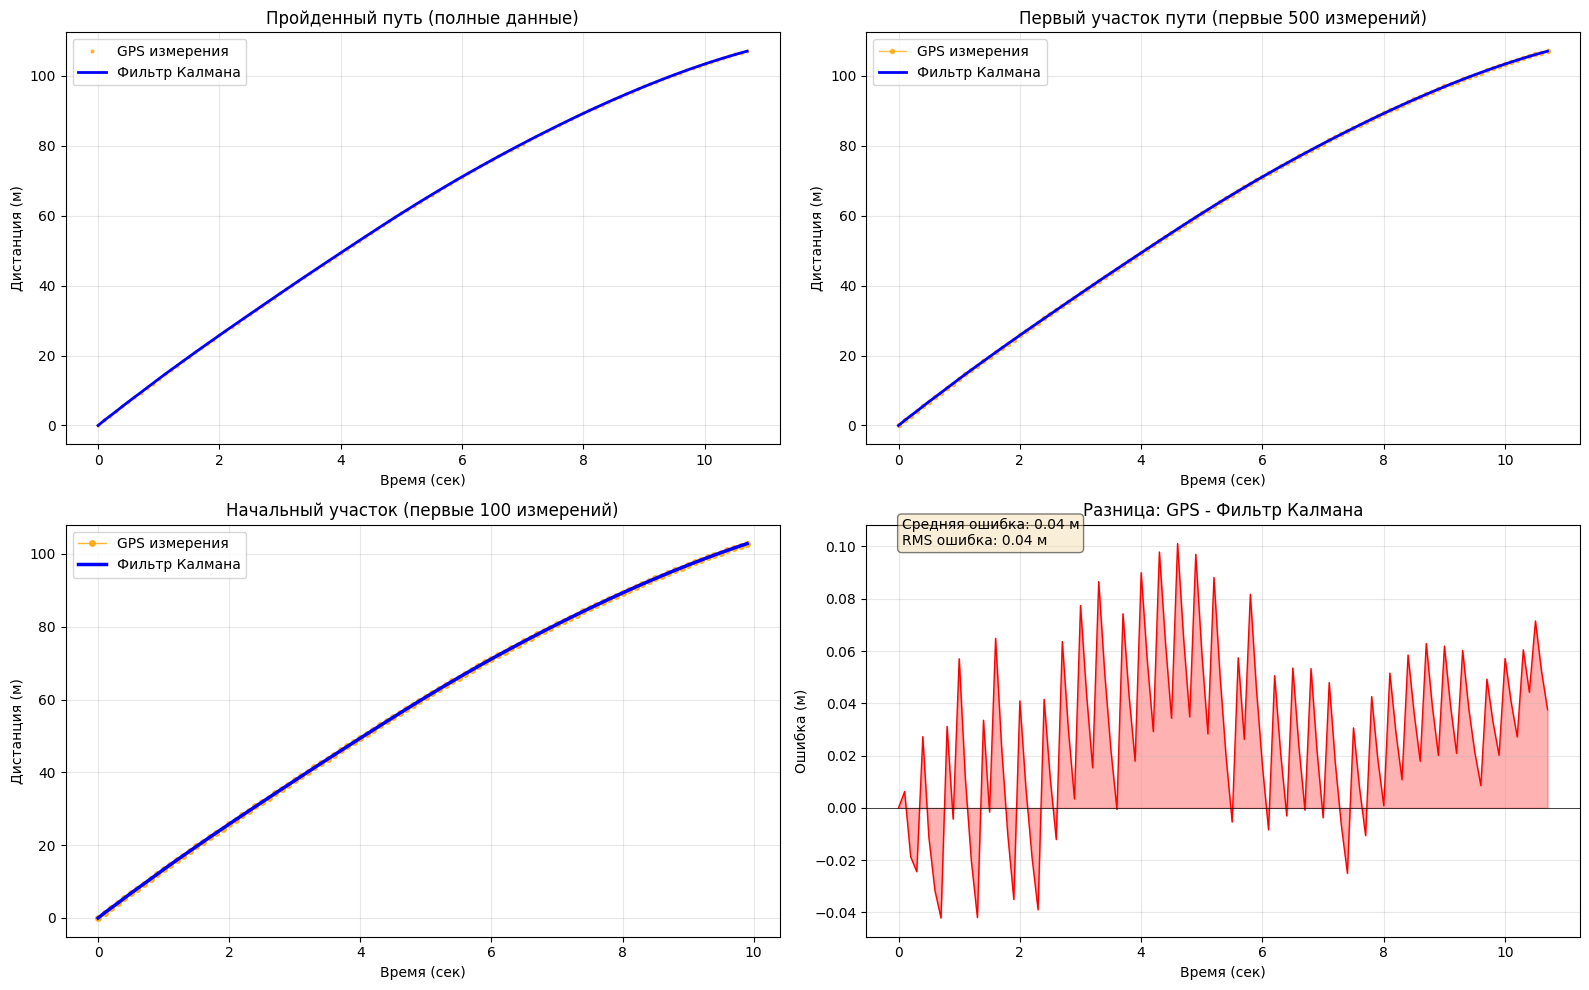

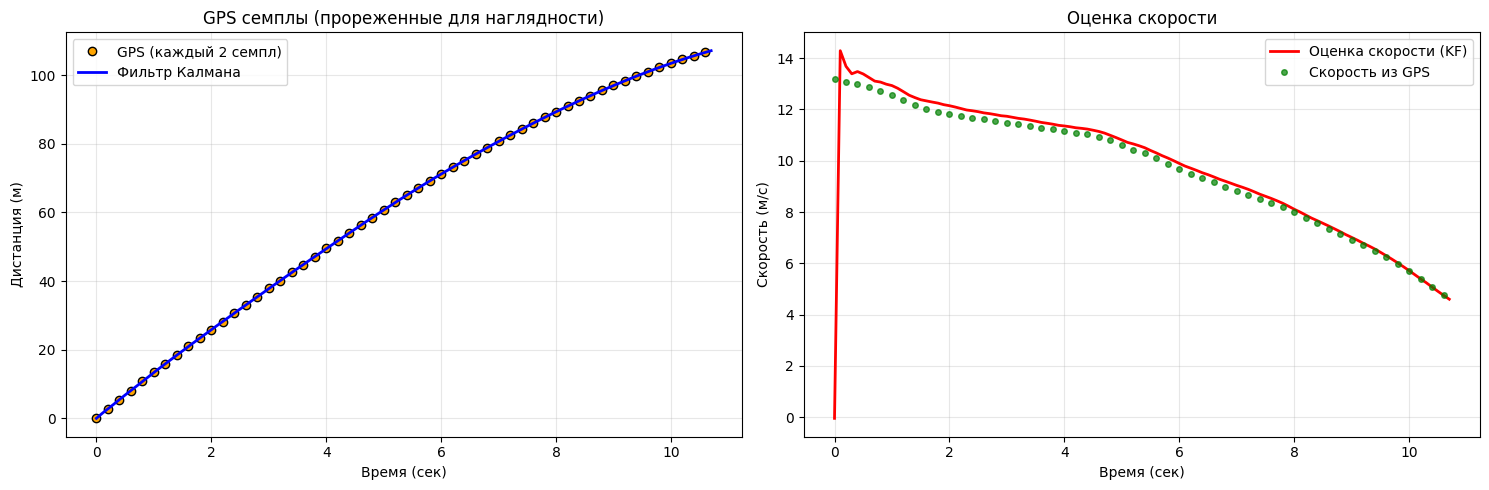


РЕЗУЛЬТАТЫ:
Итоговая дистанция по GPS: 107.11 м
Итоговая дистанция по KF:   107.08 м
Разница: 0.04 м
Среднеквадратичная ошибка: 0.04 м

Результаты сохранены в kf_results.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from geopy.distance import distance
import warnings
warnings.filterwarnings('ignore')

# --- 1. Загружаем ВСЕ данные (не только первые 10) ---
print("Загружаем все данные...")
data_files = sorted([f for f in os.listdir(oxts_path) if f.endswith('.txt')])
all_data = [np.loadtxt(os.path.join(oxts_path, f)) for f in data_files]
df = pd.DataFrame(all_data)

# Называем колонки
df.columns = ['lat', 'lon', 'alt', 'roll', 'pitch', 'yaw', 'vn', 've', 'vf', 'vl', 'vu',
              'ax', 'ay', 'az', 'af', 'al', 'au', 'wx', 'wy', 'wz', 'wf', 'wl', 'wu',
              'pos_accuracy', 'vel_accuracy', 'navstat', 'numsats', 'posmode', 'velmode', 'orimode']

print(f"Загружено {len(df)} записей")

# --- 2. Считаем дистанцию по GPS ---
def gps_distance(lat1, lon1, lat2, lon2):
    return distance((lat1, lon1), (lat2, lon2)).meters

start_lat, start_lon = df['lat'].iloc[0], df['lon'].iloc[0]
gps_distances = [0.0]
for i in range(1, len(df)):
    delta = gps_distance(df['lat'].iloc[i-1], df['lon'].iloc[i-1],
                         df['lat'].iloc[i], df['lon'].iloc[i])
    gps_distances.append(gps_distances[-1] + delta)
df['gps_distance_m'] = gps_distances

print(f"Общая дистанция по GPS: {df['gps_distance_m'].iloc[-1]:.2f} м")

# --- 3. Оцениваем шумы ---
noise_samples = min(50, len(df)//10)
gps_deltas_noise = np.diff(df['gps_distance_m'][:noise_samples])
std_meas = np.std(gps_deltas_noise) if len(gps_deltas_noise) > 0 else 1.0
std_acc = np.std(df['ax'][:noise_samples])

print(f"Шум измерения GPS: {std_meas:.4f} м")
print(f"Шум акселерометра: {std_acc:.4f} м/с²")

# --- 4. Фильтр Калмана ---
dt = 0.1  # 10 Гц для KITTI

# Матрицы
A = np.array([[1, dt],
              [0, 1]])
B = np.array([[0.5*dt**2],
              [dt]])
H = np.array([[1, 0]])

# Ковариации
Q = np.array([[ (dt**4)/4, (dt**3)/2 ],
              [ (dt**3)/2,  dt**2 ]]) * (std_acc**2)
R = np.array([[std_meas**2]])

# Начальное состояние
x = np.array([[0.0],
              [0.0]])
P = np.eye(2) * 100

# Массивы для результатов
filtered_pos = []
filtered_vel = []

print("Запускаем фильтр Калмана...")
for i in range(len(df)):
    # Управление - ускорение по оси X
    u = df['ax'].iloc[i]

    # Predict
    x = A @ x + B * u
    P = A @ P @ A.T + Q

    # Update с измерением GPS
    z = df['gps_distance_m'].iloc[i]
    y = z - (H @ x)[0, 0]
    S = H @ P @ H.T + R
    K = P @ H.T / S[0, 0]
    x = x + K * y
    P = (np.eye(2) - K @ H) @ P

    filtered_pos.append(x[0, 0])
    filtered_vel.append(x[1, 0])

df['kf_position_m'] = filtered_pos
df['kf_velocity'] = filtered_vel

# --- 5. Строим наглядные графики ---
plt.figure(figsize=(16, 10))

# График 1: Полный путь с акцентом на GPS
plt.subplot(2, 2, 1)
plt.plot(df.index * dt, df['gps_distance_m'], 'o', markersize=2, label='GPS измерения', color='orange', alpha=0.7)
plt.plot(df.index * dt, df['kf_position_m'], '-', linewidth=2, label='Фильтр Калмана', color='blue')
plt.xlabel('Время (сек)')
plt.ylabel('Дистанция (м)')
plt.title('Пройденный путь (полные данные)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Первые 500 измерений (чтобы увидеть оба графика)
plt.subplot(2, 2, 2)
plt.plot(df.index[:500] * dt, df['gps_distance_m'][:500], 'o-', markersize=3, label='GPS измерения', color='orange', alpha=0.7, linewidth=1)
plt.plot(df.index[:500] * dt, df['kf_position_m'][:500], '-', linewidth=2, label='Фильтр Калмана', color='blue')
plt.xlabel('Время (сек)')
plt.ylabel('Дистанция (м)')
plt.title('Первый участок пути (первые 500 измерений)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Зум на начало (первые 100 измерений)
plt.subplot(2, 2, 3)
plt.plot(df.index[:100] * dt, df['gps_distance_m'][:100], 'o-', markersize=4, label='GPS измерения', color='orange', alpha=0.8, linewidth=1)
plt.plot(df.index[:100] * dt, df['kf_position_m'][:100], '-', linewidth=2.5, label='Фильтр Калмана', color='blue')
plt.xlabel('Время (сек)')
plt.ylabel('Дистанция (м)')
plt.title('Начальный участок (первые 100 измерений)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 4: Разница между GPS и KF
plt.subplot(2, 2, 4)
difference = df['gps_distance_m'] - df['kf_position_m']
plt.plot(df.index * dt, difference, '-', color='red', linewidth=1)
plt.fill_between(df.index * dt, difference, alpha=0.3, color='red')
plt.xlabel('Время (сек)')
plt.ylabel('Ошибка (м)')
plt.title('Разница: GPS - Фильтр Калмана')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Добавим статистику на график
mean_error = np.mean(np.abs(difference))
rms_error = np.sqrt(np.mean(difference**2))
plt.text(0.05, 0.95, f'Средняя ошибка: {mean_error:.2f} м\nRMS ошибка: {rms_error:.2f} м',
         transform=plt.gca().transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# --- 6. Дополнительный график с семплами ---
plt.figure(figsize=(15, 5))

# Покажем каждый 10-й GPS семпл для наглядности
sample_step = max(1, len(df) // 50)  # Покажем примерно 50 точек

plt.subplot(1, 2, 1)
plt.plot(df.index[::sample_step] * dt, df['gps_distance_m'][::sample_step], 'o',
         markersize=6, label='GPS (каждый {} семпл)'.format(sample_step), color='orange', markeredgecolor='black')
plt.plot(df.index * dt, df['kf_position_m'], '-', linewidth=2, label='Фильтр Калмана', color='blue')
plt.xlabel('Время (сек)')
plt.ylabel('Дистанция (м)')
plt.title('GPS семплы (прореженные для наглядности)')
plt.legend()
plt.grid(True, alpha=0.3)

# График скорости
plt.subplot(1, 2, 2)
plt.plot(df.index * dt, df['kf_velocity'], '-', linewidth=2, label='Оценка скорости (KF)', color='red')
plt.plot(df.index[::sample_step] * dt, np.sqrt(df['vn'][::sample_step]**2 + df['ve'][::sample_step]**2),
         'o', markersize=4, label='Скорость из GPS', color='green', alpha=0.7)
plt.xlabel('Время (сек)')
plt.ylabel('Скорость (м/с)')
plt.title('Оценка скорости')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 6. Итоговый результат ---
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ:")
print("="*50)
print(f"Итоговая дистанция по GPS: {df['gps_distance_m'].iloc[-1]:.2f} м")
print(f"Итоговая дистанция по KF:   {df['kf_position_m'].iloc[-1]:.2f} м")
print(f"Разница: {abs(df['gps_distance_m'].iloc[-1] - df['kf_position_m'].iloc[-1]):.2f} м")

# Оценка качества (RMS ошибка)
rms_error = np.sqrt(np.mean((df['gps_distance_m'] - df['kf_position_m'])**2))
print(f"Среднеквадратичная ошибка: {rms_error:.2f} м")

# --- 7. Сохраняем результаты в CSV (на всякий случай) ---
output_df = df[['gps_distance_m', 'kf_position_m', 'kf_velocity']].copy()
output_df.to_csv('kf_results.csv', index=False)
print("\nРезультаты сохранены в kf_results.csv")